In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_csv("VideoGames_sales.csv")

In [3]:
a = df.loc[df['Genre'] == 'Action']
a

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
16,Grand Theft Auto V,PS3,2013.0,Action,Take-Two Interactive,7.02,9.09,0.98,3.96,21.04,97.0,50.0,8.2,3994.0,Rockstar North,M
17,Grand Theft Auto: San Andreas,PS2,2004.0,Action,Take-Two Interactive,9.43,0.40,0.41,10.57,20.81,95.0,80.0,9,1588.0,Rockstar North,M
23,Grand Theft Auto V,X360,2013.0,Action,Take-Two Interactive,9.66,5.14,0.06,1.41,16.27,97.0,58.0,8.1,3711.0,Rockstar North,M
24,Grand Theft Auto: Vice City,PS2,2002.0,Action,Take-Two Interactive,8.41,5.49,0.47,1.78,16.15,95.0,62.0,8.7,730.0,Rockstar North,M
38,Grand Theft Auto III,PS2,2001.0,Action,Take-Two Interactive,6.99,4.51,0.30,1.30,13.10,97.0,56.0,8.5,664.0,DMA Design,M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16696,Metal Gear Solid V: Ground Zeroes,PC,2014.0,Action,Konami Digital Entertainment,0.00,0.01,0.00,0.00,0.01,80.0,20.0,7.6,412.0,Kojima Productions,M
16698,Carmageddon 64,N64,1999.0,Action,Virgin Interactive,0.01,0.00,0.00,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN
16699,Planet Monsters,GBA,2001.0,Action,Titus,0.01,0.00,0.00,0.00,0.01,67.0,9.0,tbd,NaN,Planet Interactive,E
16703,The Longest 5 Minutes,PSV,2016.0,Action,Nippon Ichi Software,0.00,0.00,0.01,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.isnull().sum()

Name                  2
Platform              0
Year_of_Release     269
Genre                 2
Publisher            54
NA_Sales              0
EU_Sales              0
JP_Sales              0
Other_Sales           0
Global_Sales          0
Critic_Score       8582
Critic_Count       8582
User_Score         6704
User_Count         9129
Developer          6623
Rating             6769
dtype: int64

In [5]:
df.ffill(inplace=True)
df.isnull().sum()

Name               0
Platform           0
Year_of_Release    0
Genre              0
Publisher          0
NA_Sales           0
EU_Sales           0
JP_Sales           0
Other_Sales        0
Global_Sales       0
Critic_Score       0
Critic_Count       0
User_Score         0
User_Count         0
Developer          0
Rating             0
dtype: int64

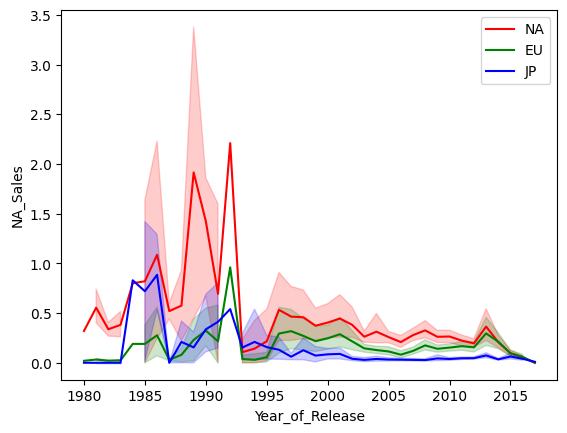

In [6]:
# 1. Numerical - Numerical
# Line plot
sns.lineplot(data=a, x='Year_of_Release', y='NA_Sales', label= "NA", color="red")
sns.lineplot(data=a, x='Year_of_Release', y='EU_Sales', label= "EU", color="green")
sns.lineplot(data=a, x='Year_of_Release', y='JP_Sales', label= "JP", color="blue")
plt.legend(loc= 'upper right')
plt.show()

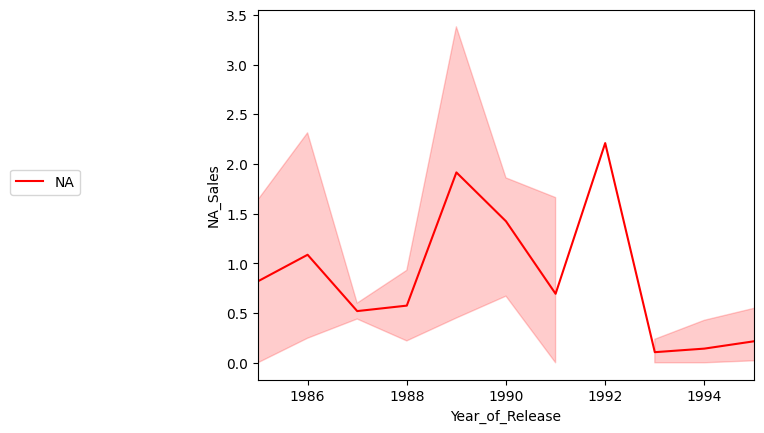

In [7]:
sns.lineplot(data=a, x='Year_of_Release', y='NA_Sales', label= "NA", color="red")
plt.xlim(1985, 1995)
plt.legend(loc=(-0.5,0.5))  #we can put legend outside the graph
plt.show()

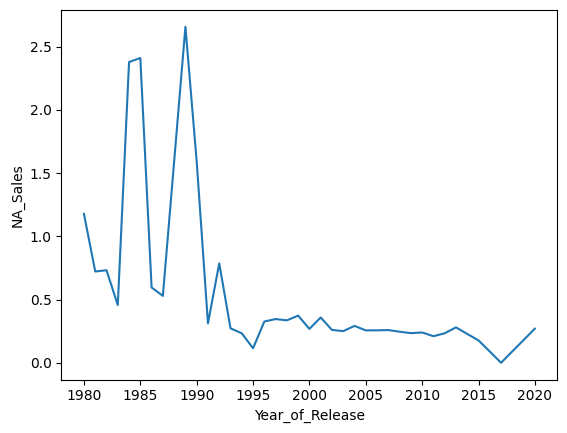

In [8]:
sns.lineplot(data = df, x = "Year_of_Release", y = "NA_Sales", errorbar=None) 
plt.show()
# errorbar is used to remove that shaded area on the graph

<Axes: xlabel='Year_of_Release', ylabel='NA_Sales'>

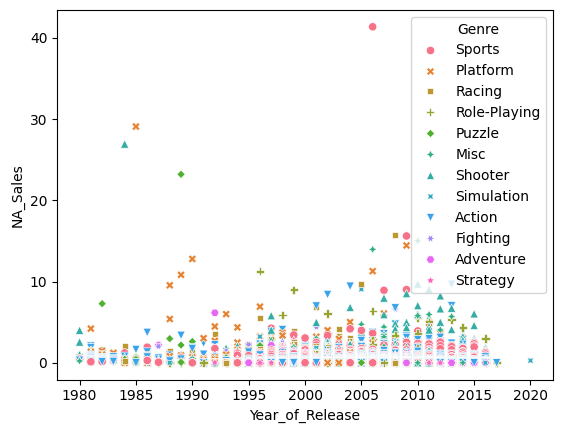

In [9]:
sns.scatterplot(data=df, x = "Year_of_Release", y = "NA_Sales", hue="Genre", style="Genre") 
# hue is for colours 
# style is for different symbols of styling

In [10]:
# 2. Categorical - Categorical
pub = df["Publisher"].value_counts().index[:5] # top five publishers
plat = df["Platform"].value_counts().index[:5] # top five publishers
gen = df["Genre"].value_counts().index[:5] # top five publishers

In [11]:
print(pub)
print(plat)
print(gen)

Index(['Electronic Arts', 'Activision', 'Namco Bandai Games', 'Ubisoft',
       'Konami Digital Entertainment'],
      dtype='object', name='Publisher')
Index(['PS2', 'DS', 'PS3', 'Wii', 'X360'], dtype='object', name='Platform')
Index(['Action', 'Sports', 'Misc', 'Role-Playing', 'Shooter'], dtype='object', name='Genre')


In [12]:
top5_data = df.loc[(df['Genre'].isin(gen) & df['Platform'].isin(plat) & df['Publisher'].isin(pub))]
top5_data

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
29,Call of Duty: Modern Warfare 3,X360,2011.0,Shooter,Activision,9.04,4.24,0.13,1.32,14.73,88.0,81.0,3.4,8713.0,"Infinity Ward, Sledgehammer Games",M
32,Call of Duty: Black Ops,X360,2010.0,Shooter,Activision,9.70,3.68,0.11,1.13,14.61,87.0,89.0,6.3,1454.0,Treyarch,M
34,Call of Duty: Black Ops II,PS3,2012.0,Shooter,Activision,4.99,5.73,0.65,2.42,13.79,83.0,21.0,5.3,922.0,Treyarch,M
35,Call of Duty: Black Ops II,X360,2012.0,Shooter,Activision,8.25,4.24,0.07,1.12,13.67,83.0,73.0,4.8,2256.0,Treyarch,M
36,Call of Duty: Modern Warfare 2,X360,2009.0,Shooter,Activision,8.52,3.59,0.08,1.28,13.47,94.0,100.0,6.3,2698.0,Infinity Ward,M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16646,Hirameki Action: Chibikko Wagyan no Daiki na B...,DS,2009.0,Action,Namco Bandai Games,0.00,0.00,0.01,0.00,0.01,51.0,8.0,3.8,29.0,Big Red Software,E10+
16651,Metal Gear Solid HD Edition,X360,2011.0,Action,Konami Digital Entertainment,0.00,0.00,0.01,0.00,0.01,51.0,8.0,tbd,5.0,Konami,M
16658,Ben 10 Omniverse 2,X360,2013.0,Action,Namco Bandai Games,0.00,0.01,0.00,0.00,0.01,81.0,46.0,5.1,9.0,High Voltage Software,E10+
16660,Imagine Figure Skater (JP sales),DS,2007.0,Sports,Ubisoft,0.00,0.00,0.01,0.00,0.01,81.0,46.0,tbd,9.0,49Games,E10+


<Axes: xlabel='Publisher', ylabel='count'>

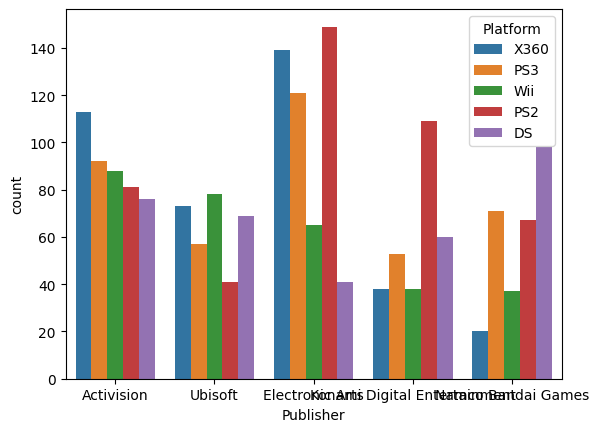

In [13]:
# I) Dodge CountPlot
sns.countplot(data=top5_data, x="Publisher", hue="Platform")

In [14]:
# sns.countplot(data=df, x="Genre", hue="Publisher")
# This is also possible but there are many Publishers and Genre 
# So we have taken top 5 

In [15]:
# II) Stacked CountPlot
counts1 = top5_data.groupby(["Publisher", "Genre"]).size().unstack(fill_value=0)
counts1

Genre,Action,Misc,Role-Playing,Shooter,Sports
Publisher,,,,,
Activision,176,86,15,86,87
Electronic Arts,101,41,15,66,292
Konami Digital Entertainment,83,54,9,14,138
Namco Bandai Games,121,65,65,21,21
Ubisoft,82,121,20,44,51


In [16]:
# or 
counts2 = pd.crosstab(index=top5_data['Publisher'], columns=top5_data['Platform'])
counts2


Platform,DS,PS2,PS3,Wii,X360
Publisher,,,,,
Activision,76,81,92,88,113
Electronic Arts,41,149,121,65,139
Konami Digital Entertainment,60,109,53,38,38
Namco Bandai Games,98,67,71,37,20
Ubisoft,69,41,57,78,73


<Axes: xlabel='Publisher'>

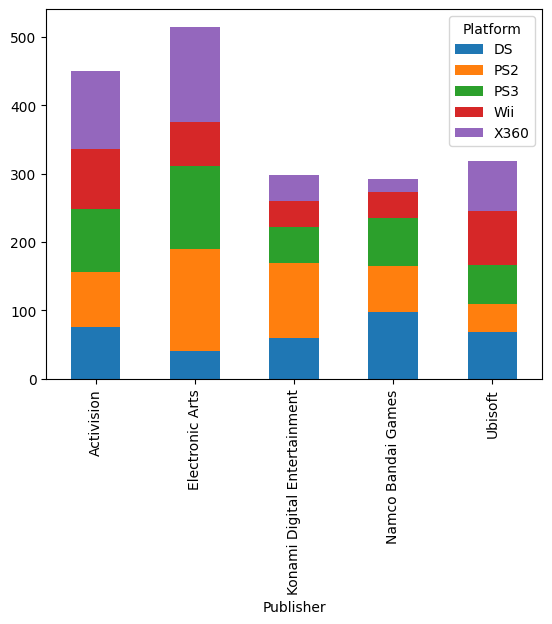

In [17]:
counts2.plot(kind="bar", stacked=True) # it will give doged countplot when (stacked = false)  

<Axes: xlabel='Genre', ylabel='Year_of_Release'>

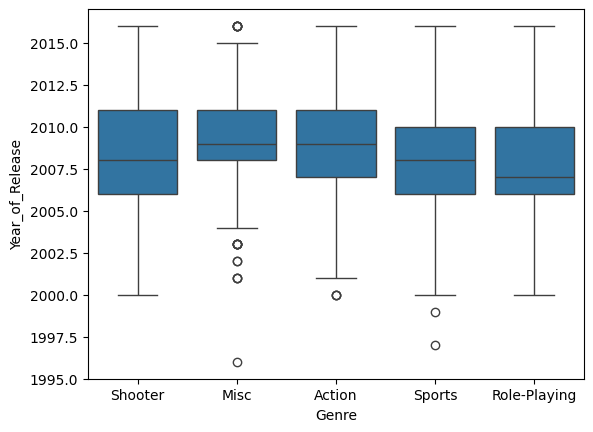

In [18]:
sns.boxplot(data= top5_data, x='Genre', y='Year_of_Release')

In [19]:
numeric_data = top5_data.select_dtypes(include="number")
numeric_data

,Year_of_Release,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Count
29,2011.0,9.04,4.24,0.13,1.32,14.73,88.0,81.0,8713.0
32,2010.0,9.70,3.68,0.11,1.13,14.61,87.0,89.0,1454.0
34,2012.0,4.99,5.73,0.65,2.42,13.79,83.0,21.0,922.0
35,2012.0,8.25,4.24,0.07,1.12,13.67,83.0,73.0,2256.0
36,2009.0,8.52,3.59,0.08,1.28,13.47,94.0,100.0,2698.0
...,...,...,...,...,...,...,...,...,...
16646,2009.0,0.00,0.00,0.01,0.00,0.01,51.0,8.0,29.0
16651,2011.0,0.00,0.00,0.01,0.00,0.01,51.0,8.0,5.0
16658,2013.0,0.00,0.01,0.00,0.00,0.01,81.0,46.0,9.0
16660,2007.0,0.00,0.00,0.01,0.00,0.01,81.0,46.0,9.0


<Axes: >

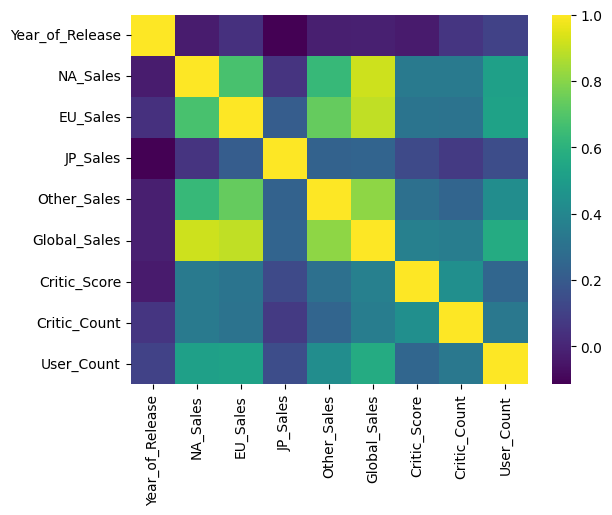

In [20]:
sns.heatmap(numeric_data.corr(), cmap="viridis") 
# cmap = color map (default = rocket)
# viridis, rocket, YlGnBu, magma, coolwarm, crest, coolwarm_r (by adding '_r' at last we can achive reverse colours)

<Axes: >

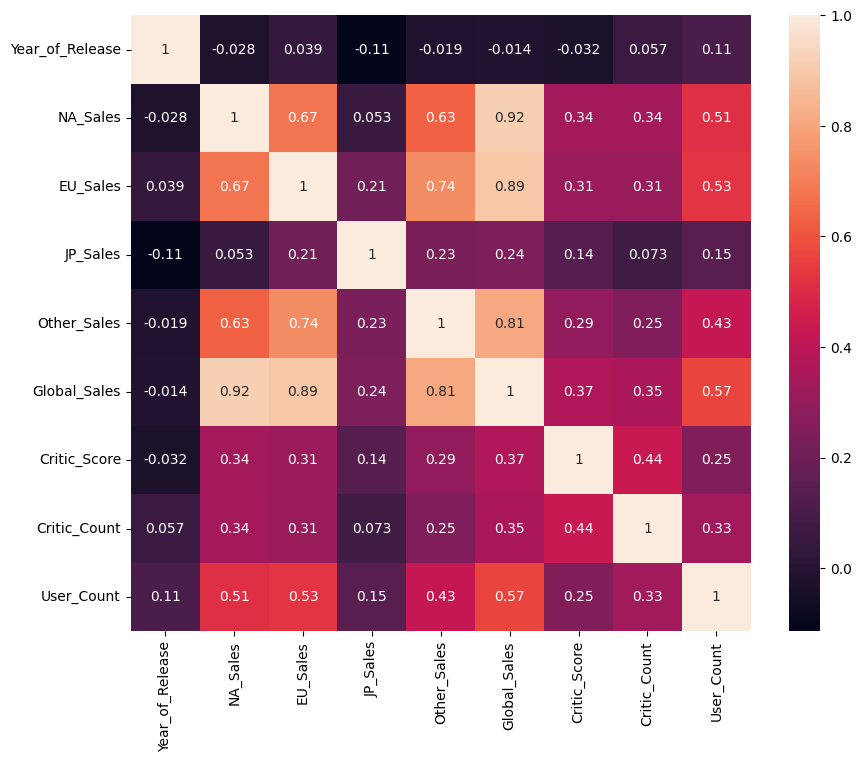

In [21]:
plt.figure(figsize=(10,8))
sns.heatmap(numeric_data.corr(), annot=True)  # annot = True (gives us values for all)


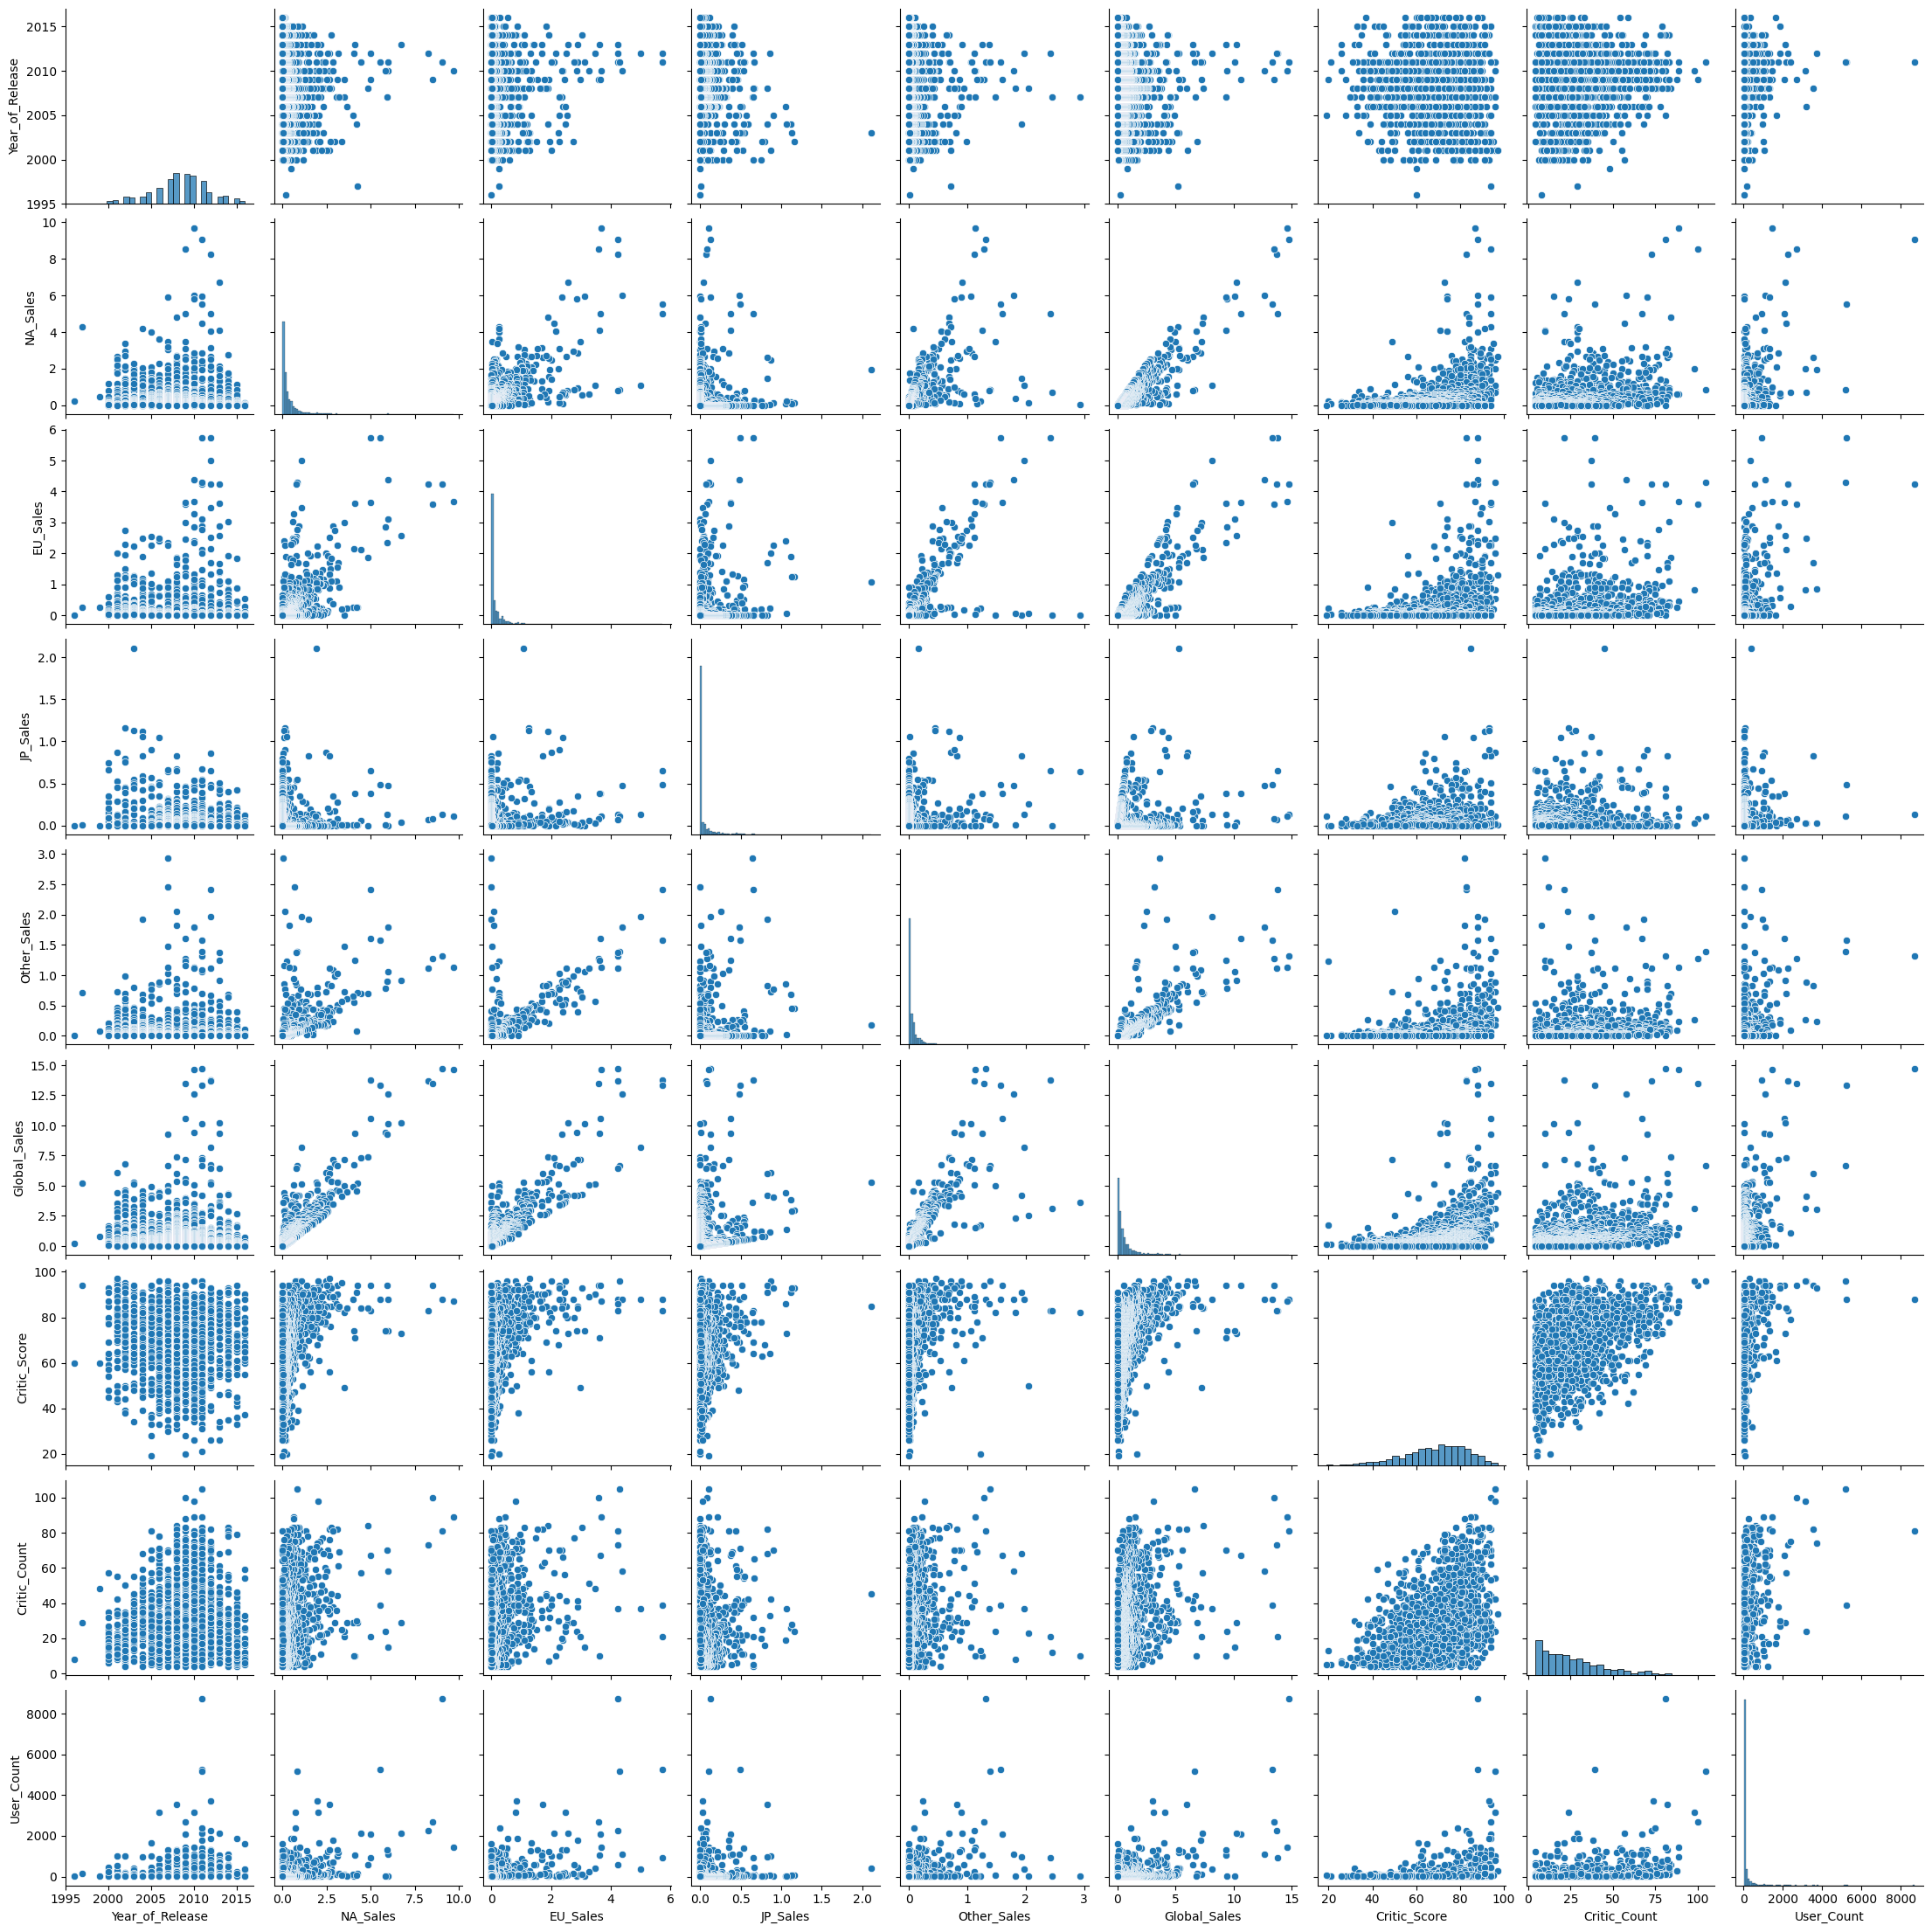

In [22]:
# pair plot
sns.pairplot(numeric_data)

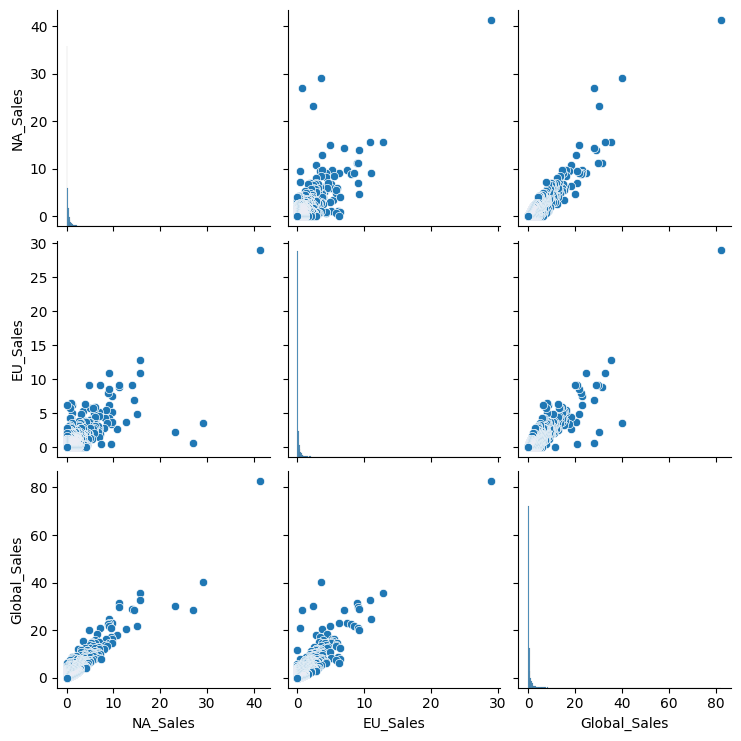

In [23]:
sns.pairplot(df[["NA_Sales", "EU_Sales", "Global_Sales"]])

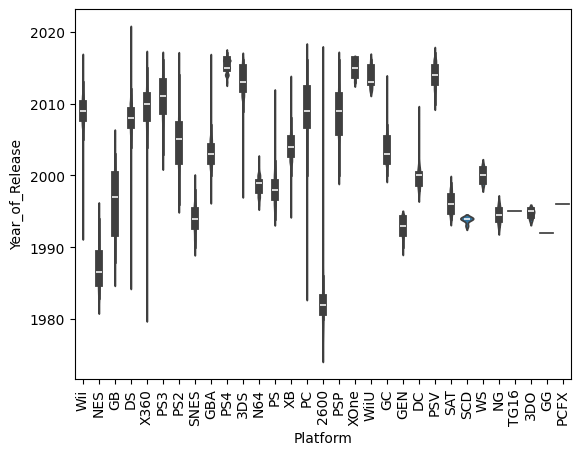

In [24]:
sns.violinplot(x="Platform", y="Year_of_Release", data=df)
plt.xticks(rotation=90)
plt.show()

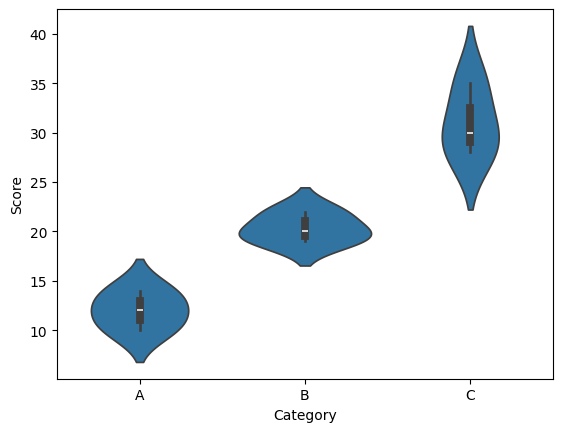

In [ ]:
data = {
    "Category": ['A', 'A', 'A', 'B', 'B', 'B', 'C', 'C', 'C'],
    "Score": [10, 12, 14, 20, 22, 19, 30, 28, 35]
}
df1 = pd.DataFrame(data)
sns.violinplot(df1, x="Category", y="Score")
plt.show()
# inner structure is boxplot
# outer is showing density 

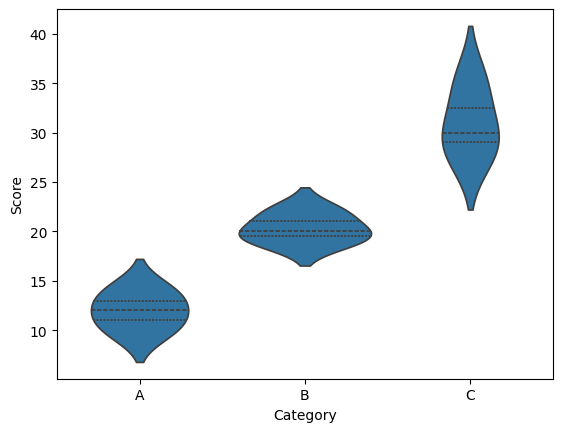

In [31]:
sns.violinplot(df1, x="Category", y="Score", inner="quartile")
plt.show()

In [26]:
# you can check different arguments for different functions on seaborn website